# Topic Modeling for Course Classification Analysis

**Purpose**: Unsupervised analysis of Stockholm University course descriptions using LDA topic modeling.

**Goals**:
1. Discover latent topics in course descriptions
2. Analyze how discovered topics align with official UO (disciplinary domain) labels
3. Identify courses where topic distribution diverges from official classification
4. Provide interpretable insights for domain expert discussion

**Methods**:
- LDA (Latent Dirichlet Allocation) for topic discovery
- Topic-label correlation analysis
- Visualization with pyLDAvis and matplotlib

In [3]:
# ========================
# Imports and Setup
# ========================
import pandas as pd
import numpy as np
import re
import json
from pathlib import Path
from collections import Counter

# Topic modeling
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation, NMF
from sklearn.preprocessing import MultiLabelBinarizer

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# For interactive LDA visualization
try:
    import pyLDAvis
    import pyLDAvis.lda_model
    PYLDAVIS_AVAILABLE = True
except ImportError:
    print("pyLDAvis not available. Install with: pip install pyLDAvis")
    PYLDAVIS_AVAILABLE = False

import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_colwidth', 120)

print('Imports ok.')

Imports ok.


In [4]:
# ========================
# Configuration
# ========================

# Update these paths for your Kaggle environment
DATA_DIR = Path('/kaggle/input/course-descriptions-2023-raw')
CSV_PATH = DATA_DIR / 'Kursplanekorpus-2023-original-ej-bearb.csv'

# Output directories
ARTIFACTS_DIR = Path('/kaggle/working/topic_modeling')
ARTIFACTS_DIR.mkdir(exist_ok=True, parents=True)

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Column names
ID_COL = "id"
UO_COL = "education_area_list_id"
PCT_COL = "percentage"
TEXT_COLS = ["name", "plan_description", "objectives"]
DATE_COLS = ["decision_date", "start_date"]

# UO code to name mapping (based on Swedish disciplinary domains)

UO_NAMES = {
    2434: "HU",  # Humaniora
    2436: "JU",  # Juridik
    2438: "LU",  # Lärarutbildning  
    2439: "ME",  # Medicin
    2441: "NA",  # Naturvetenskap
    2442: "SA",  # Samhällsvetenskap
    2444: "TE",  # Teknik
    2445: "VÅ",  # Vård
    2447: "ÖV",  # Övrigt
    2451: "VU"   # Verksamhetsförlagd utbildning
}

print('Configuration ok.')

Configuration ok.


## 1. Data Loading and Preprocessing

We use the same preprocessing as in the baseline notebook to ensure consistency.

In [5]:
# Helper Functions
# TODO: These should be imported from su_utils


def join_uo_by_course_version(df, id_col="id", date_col="decision_date", 
                               uo_col="uo_code", pct_col="uo_percentage"):
    """Combine all rows with same (id, decision_date) into one conceptual row."""
    df = df.copy()
    
    df[id_col] = pd.to_numeric(df[id_col], errors="coerce")
    df[uo_col] = pd.to_numeric(df[uo_col], errors="coerce")
    df[pct_col] = (
        df[pct_col].astype(str).str.replace(",", ".", regex=False)
                   .pipe(pd.to_numeric, errors="coerce")
    )
    df[date_col] = pd.to_datetime(df[date_col], errors="coerce")
    
    df = df.dropna(subset=[id_col, date_col, uo_col])
    
    def pack(g):
        uos = tuple(g[uo_col].dropna().astype(int))
        pcts = tuple(g[pct_col].dropna().astype(float))
        row = g.iloc[0].copy()
        row["labels_uo"] = uos
        row["labels_pct"] = pcts
        return row
    
    out = df.groupby([id_col, date_col], as_index=False).apply(pack)
    out = out.drop(columns=[uo_col, pct_col], errors="ignore")
    
    return out.reset_index(drop=True)


def primary_from_labels(uos, pcts):
    """Given tuples of UOs and percentages, return primary UO (highest pct or first)."""
    if isinstance(uos, (list, tuple)) and len(uos) > 0:
        if isinstance(pcts, (list, tuple)) and len(pcts) == len(uos) and len(pcts) > 0:
            return int(uos[int(np.argmax(pcts))])
        return int(uos[0])
    return np.nan


def build_text(row, cols):
    """Combine text columns into one modeling text field."""
    parts = []
    for c in cols:
        val = row.get(c, None)
        if val is not None and str(val).strip():
            parts.append(str(val))
    return "\n".join(parts)


def clean_text(s):
    """Clean text by removing HTML tags and collapsing whitespace."""
    if not isinstance(s, str):
        return ""
    s = s.replace("\r", " ").replace("\n", " ")
    s = re.sub(r"<[^>]+>", " ", s)  # remove HTML/XML-like tags
    s = re.sub(r"\s+", " ", s)       # collapse whitespace
    return s.strip()

print('Helper functions defined.')

Helper functions defined.


In [6]:
# ========================
# Load and Preprocess Data
# ========================

# Load raw data
df_raw = pd.read_csv(CSV_PATH, sep=";", low_memory=False)
print(f"Raw data loaded: {len(df_raw)} rows")

# Rename columns for clarity
df = df_raw.rename(columns={
    "education_area_list_id": "uo_code",
    "percentage": "uo_percentage",
})

# Convert date columns
for date_col in DATE_COLS:
    df[date_col] = pd.to_datetime(df[date_col], errors='coerce')

# Parse UO columns
df["uo_code"] = pd.to_numeric(df["uo_code"], errors="coerce").astype("Int64")
df["uo_percentage"] = (
    df["uo_percentage"].astype(str).str.replace(",", ".", regex=False)
                       .pipe(pd.to_numeric, errors="coerce")
)

# Join UO info by course version
df_joined = join_uo_by_course_version(df)
df = df_joined

# Add primary UO
df["primary_uo"] = df.apply(
    lambda r: primary_from_labels(r["labels_uo"], r["labels_pct"]),
    axis=1
)
df = df.dropna(subset=["primary_uo"])
df["primary_uo"] = df["primary_uo"].astype(int)

print(f"After joining and processing: {len(df)} course versions")
print(f"Unique courses: {df['id'].nunique()}")

Raw data loaded: 12948 rows
After joining and processing: 9770 course versions
Unique courses: 4880


In [7]:
# ========================
# Build Text Field
# ========================

# Concatenate and clean text
df["text"] = df.apply(build_text, axis=1, args=(TEXT_COLS,))
df["text"] = df["text"].apply(clean_text)
df = df[df["text"].str.len() > 10]  # drop tiny rows

# Add label set for analysis
df["label_set"] = df["labels_uo"].apply(lambda t: frozenset(t))
df["n_labels"] = df["labels_uo"].apply(len)
df["is_multilabel"] = df["n_labels"] > 1

print(f"\nFinal dataset: {len(df)} course versions")
print(f"Multi-label courses: {df['is_multilabel'].sum()} ({100*df['is_multilabel'].mean():.1f}%)")
print(f"\nPrimary UO distribution:")
print(df["primary_uo"].value_counts().sort_index())


Final dataset: 9770 course versions
Multi-label courses: 2682 (27.5%)

Primary UO distribution:
primary_uo
2434    3332
2436     452
2438     317
2439     327
2441    1691
2442    2234
2444     457
2445     157
2447     684
2451     119
Name: count, dtype: int64


## 2. Swedish Text Preprocessing for Topic Modeling

For LDA to work well, we need to:
1. Remove Swedish stopwords
2. Handle Swedish-specific characters
3. Possibly lemmatize (optional, using simple approach)

In [8]:
# Swedish Stopwords
# TODO: Use NLTK or some other standard method

# Extended Swedish stopwords list
SWEDISH_STOPWORDS = {
    # Basic stopwords
    'och', 'i', 'att', 'en', 'det', 'som', 'för', 'på', 'är', 'av', 'med', 'till',
    'den', 'har', 'de', 'inte', 'om', 'ett', 'vi', 'vara', 'kan', 'man', 'sig',
    'eller', 'så', 'ska', 'var', 'från', 'vid', 'efter', 'utan', 'mot', 'också',
    'hans', 'hon', 'hennes', 'då', 'nu', 'hur', 'vad', 'här', 'där', 'när', 'upp',
    'ut', 'in', 'alla', 'andra', 'under', 'över', 'mellan', 'denna', 'detta',
    'dessa', 'genom', 'inom', 'samt', 'även', 'dock', 'endast', 'vilka', 'vilket',
    
    # Course-specific stopwords (administrative language)
    'kursen', 'kurs', 'student', 'studenten', 'studerande', 'studierna',
    'moment', 'momentet', 'hp', 'högskolepoäng', 'poäng',
    'examineras', 'examination', 'prov', 'betyg', 'betygssättning',
    'godkänt', 'godkänd', 'underkänd', 'underkänt',
    'kursplan', 'kursplanen', 'kurslitteratur', 'litteratur',
    'föreläsningar', 'föreläsning', 'seminarium', 'seminarier', 'övningar', 'övning',
    'undervisning', 'undervisningen', 'lärare', 'examinator',
    'skriftlig', 'skriftliga', 'skriftligt', 'muntlig', 'muntliga', 'muntligt',
    'obligatorisk', 'obligatoriska', 'obligatoriskt',
    'följande', 'enligt', 'avseende', 'gällande', 'angående',
    'se', 'sid', 'sidan', 'kap', 'kapitel', 'del', 'delar', 'delarna',
    
    # Common verbs and forms
    'kunna', 'skall', 'ska', 'bör', 'får', 'måste', 'vill',
    'ha', 'hade', 'haft', 'har', 'blir', 'blev', 'blivit',
    'ge', 'ger', 'gav', 'gett', 'given', 'givna', 'givet',
    'göra', 'gör', 'gjort', 'gjorda',
    'ta', 'tar', 'tog', 'tagit', 'tagen', 'tagna',
    
    # Prepositions and conjunctions
    'angående', 'beträffande', 'avseende', 'rörande',
    'såsom', 'såväl', 'både', 'antingen', 'varken',
    'medan', 'eftersom', 'därför', 'alltså', 'därav', 'härav',
    
    # Numbers and ordinals
    'en', 'ett', 'två', 'tre', 'fyra', 'fem', 'sex', 'sju', 'åtta', 'nio', 'tio',
    'första', 'andra', 'tredje', 'fjärde', 'femte',
    
    # Pronouns
    'jag', 'du', 'han', 'hon', 'den', 'det', 'vi', 'ni', 'de',
    'mig', 'dig', 'honom', 'henne', 'oss', 'er', 'dem',
    'min', 'mitt', 'mina', 'din', 'ditt', 'dina',
    'sin', 'sitt', 'sina', 'vår', 'vårt', 'våra',
    'egen', 'eget', 'egna', 'annan', 'annat', 'andra',
    'någon', 'något', 'några', 'ingen', 'inget', 'inga',
    'varje', 'all', 'allt', 'alla', 'samma', 'själv', 'själva',
}

print(f"Swedish stopwords defined: {len(SWEDISH_STOPWORDS)} words")

Swedish stopwords defined: 213 words


In [9]:
# ========================
# Text Preprocessing for LDA
# ========================

def preprocess_for_lda(text):
    """Preprocess text for LDA topic modeling."""
    if not isinstance(text, str):
        return ""
    
    # Lowercase
    text = text.lower()
    
    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)
    
    # Remove email addresses
    text = re.sub(r'\S+@\S+', '', text)
    
    # Remove course codes (like AS1002, LIN215)
    text = re.sub(r'\b[A-Za-z]{2,4}\d{3,4}[A-Za-z]?\b', '', text)
    
    # Remove numbers with units (7,5 hp, 15 hp)
    text = re.sub(r'\b\d+[,.]?\d*\s*(hp|poäng|%|kr)\b', '', text)
    
    # Keep only letters and Swedish characters
    text = re.sub(r'[^a-zåäöéüA-ZÅÄÖÉÜ\s]', ' ', text)
    
    # Collapse whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

# Apply preprocessing
df["text_lda"] = df["text"].apply(preprocess_for_lda)

# Show sample
print("Sample preprocessed text:")
print(df["text_lda"].iloc[0][:500])

Sample preprocessed text:
bevarandebiologi kursen behandlar biodiversitetens mönster och processer små populationers biologi bevarandegenetik bevarandeekologi hot mot biologisk mångfald och biologiskt förankrade bevarandeinsatser efter att ha genomgått kursen förväntas studenten kunna redovisa bevarandebiologins huvuddelar och bakgrunden till forskningsfältets framväxt kunna visa insikt om problemställningar och ha praktisk erfarenhet av analysmetodik inom modern bevarandebiologisk forskning kunna förklara hur stokastisk


In [10]:
df.columns

Index(['id', 'revoked', 'department_number', 'value', 'identifier', 'name',
       'name_en', 'credits', 'value.1', 'start_date', 'value.2', 'name.1',
       'value.3', 'name.2', 'value.4', 'Saknar huvudområde',
       'Saknar huvudområde.1', 'plan_description', 'objectives',
       'form_of_instruction', 'examination', 'literature',
       'transitional_rules', 'limitations', 'additional_information',
       'decision_date', 'decision_info', 'labels_uo', 'labels_pct',
       'primary_uo', 'text', 'label_set', 'n_labels', 'is_multilabel',
       'text_lda'],
      dtype='object')

In [11]:
#Debugging
# Check which primary_uo-värden have missing names
#missing = df[df['primary_uo_name'].isna()]['primary_uo'].unique()
#print("UO-koder utan namn:", missing)
#print("Typer:", [type(x) for x in missing])

# Check types in UO_NAMES
#print("UO_NAMES keys:", list(UO_NAMES.keys()))

## 3. LDA Topic Modeling

We'll train LDA with different numbers of topics and analyze the results.

In [12]:
# ========================
# Build Document-Term Matrix
# ========================

# CountVectorizer for LDA (LDA works with raw counts, not TF-IDF)
vectorizer = CountVectorizer(
    stop_words=list(SWEDISH_STOPWORDS),
    min_df=5,              # minimum document frequency
    max_df=0.8,            # maximum document frequency (remove too common terms)
    max_features=5000,     # limit vocabulary size
    ngram_range=(1, 2),    # unigrams and bigrams
    token_pattern=r'\b[a-zåäöéü]{3,}\b'  # at least 3 characters
)

# Fit and transform
dtm = vectorizer.fit_transform(df["text_lda"])
feature_names = vectorizer.get_feature_names_out()

print(f"Document-Term Matrix shape: {dtm.shape}")
print(f"Vocabulary size: {len(feature_names)}")
print(f"\nSample vocabulary terms: {list(feature_names[:20])}")

Document-Term Matrix shape: (9770, 5000)
Vocabulary size: 5000

Sample vocabulary terms: ['adekvat', 'adekvat sätt', 'adekvata', 'adekvata metoder', 'affärsmodeller', 'affärssystem', 'afrika', 'akademisk', 'akademisk engelska', 'akademisk spanska', 'akademisk text', 'akademiska', 'akademiska genrer', 'akademiska sammanhang', 'akademiska texter', 'akademiskt', 'akademiskt skrivande', 'akribi', 'aktiv', 'aktiva']


In [13]:
# ========================
# Train LDA Model
# ========================

# We'll use 10 topics to match the number of UO codes
# But we'll also try other values for comparison

N_TOPICS = 10  # Start with 10 (same as number of UO codes)

lda = LatentDirichletAllocation(
    n_components=N_TOPICS,
    max_iter=20,
    learning_method='online',
    random_state=RANDOM_SEED,
    n_jobs=-1,
    verbose=1
)

# Fit LDA
print(f"Training LDA with {N_TOPICS} topics...")
doc_topic_dist = lda.fit_transform(dtm)

print(f"\nLDA training complete.")
print(f"Document-topic distribution shape: {doc_topic_dist.shape}")
print(f"Perplexity: {lda.perplexity(dtm):.2f}")

Training LDA with 10 topics...
iteration: 1 of max_iter: 20
iteration: 2 of max_iter: 20
iteration: 3 of max_iter: 20
iteration: 4 of max_iter: 20
iteration: 5 of max_iter: 20
iteration: 6 of max_iter: 20
iteration: 7 of max_iter: 20
iteration: 8 of max_iter: 20
iteration: 9 of max_iter: 20
iteration: 10 of max_iter: 20
iteration: 11 of max_iter: 20
iteration: 12 of max_iter: 20
iteration: 13 of max_iter: 20
iteration: 14 of max_iter: 20
iteration: 15 of max_iter: 20
iteration: 16 of max_iter: 20
iteration: 17 of max_iter: 20
iteration: 18 of max_iter: 20
iteration: 19 of max_iter: 20
iteration: 20 of max_iter: 20

LDA training complete.
Document-topic distribution shape: (9770, 10)
Perplexity: 1194.13


In [14]:
# ========================
# Display Top Words per Topic
# ========================

def display_topics(model, feature_names, n_top_words=15):
    """Display top words for each topic."""
    topics = []
    for topic_idx, topic in enumerate(model.components_):
        top_words_idx = topic.argsort()[:-n_top_words-1:-1]
        top_words = [feature_names[i] for i in top_words_idx]
        topics.append({
            'topic': topic_idx,
            'top_words': ', '.join(top_words)
        })
        print(f"Topic {topic_idx}: {', '.join(top_words[:10])}")
    return pd.DataFrame(topics)

print("\n" + "="*60)
print("TOP WORDS PER TOPIC")
print("="*60 + "\n")
topics_df = display_topics(lda, feature_names, n_top_words=15)


TOP WORDS PER TOPIC

Topic 0: texter, delkursen, resultat, grundläggande, olika, grammatik, svenska, redogöra, text, resultat delkursen
Topic 1: delkursen, tolkning, mellanöstern, global, kunskap, visa, grundläggande, kvalitativa, arabiska, hållbar
Topic 2: visa, visa förmåga, förmåga, diskutera, kunskap, språk, forskning, identifiera, läs, utvecklingsarbete
Topic 3: olika, lärande, utifrån, utveckling, bedömning, perspektiv, elevers, barn, barns, elever
Topic 4: grundläggande, olika, metoder, behandlar, redogöra, förväntas, modeller, begrepp, genomgått, använda
Topic 5: delkursen, delkurs, redogöra, perspektiv, centrala, resultat, begrepp, olika, grundläggande, svenska
Topic 6: förmåga, visa, kunskap, förståelse, kunskap förståelse, genomgången, visa förmåga, förhållningssätt, färdighet förmåga, färdighet
Topic 7: olika, teoretiska, arbete, perspektiv, reflektera, forskning, kritiskt, teorier, socialt, analysera
Topic 8: självständigt, vetenskaplig, arbete, genomföra, kritiskt, metod

In [15]:
# ========================
# Add Topic Assignments to DataFrame
# ========================

# Dominant topic for each document
df["dominant_topic"] = doc_topic_dist.argmax(axis=1)
df["topic_confidence"] = doc_topic_dist.max(axis=1)

# Add full topic distribution
for i in range(N_TOPICS):
    df[f"topic_{i}"] = doc_topic_dist[:, i]

print("Topic assignments added to dataframe.")
print(f"\nDominant topic distribution:")
print(df["dominant_topic"].value_counts().sort_index())

Topic assignments added to dataframe.

Dominant topic distribution:
dominant_topic
0    1130
1     157
2     428
3    1100
4    2053
5    1055
6     644
7     765
8    1327
9    1111
Name: count, dtype: int64


## 4. Topic-Label Correlation Analysis

Next we analyze how the discovered topics correlate with the official UO labels.

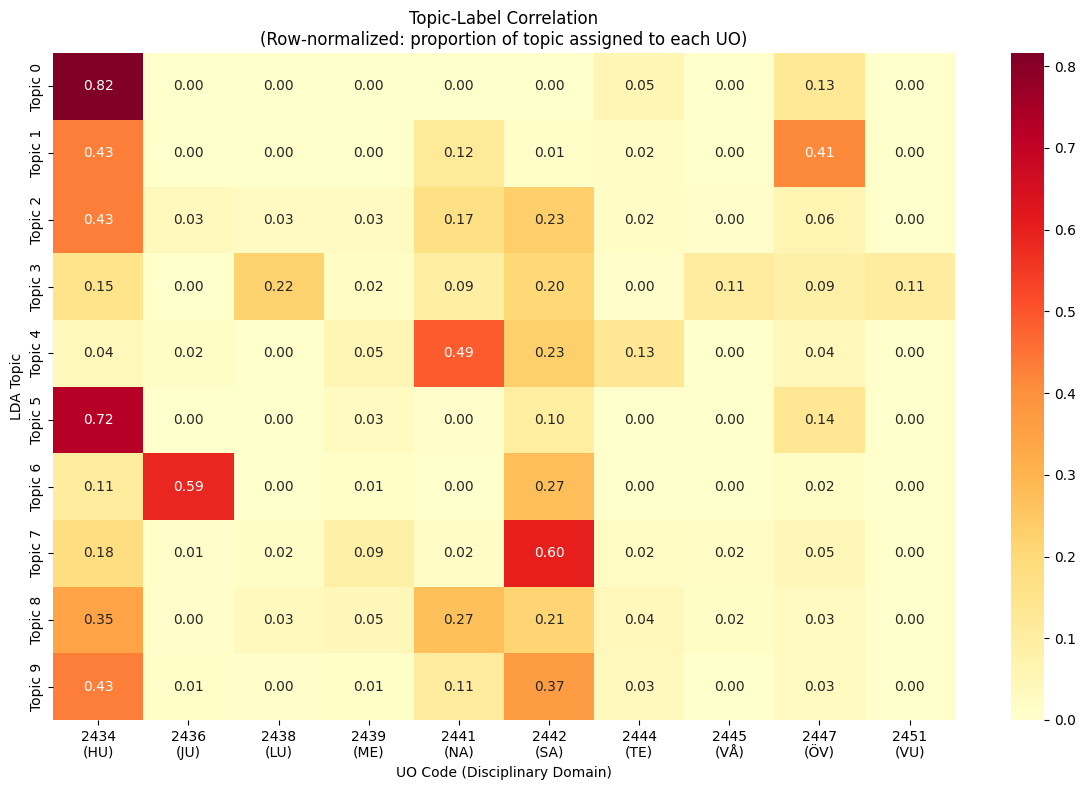


Saved: topic_uo_correlation.png


In [16]:
# ========================
# Topic-UO Correlation Matrix
# ========================

# Create a cross-tabulation of dominant topic vs primary UO
crosstab = pd.crosstab(
    df["dominant_topic"], 
    df["primary_uo"],
    normalize='index'  # normalize by topic (row)
)

# Create figure
fig, ax = plt.subplots(figsize=(12, 8))

# Heatmap
sns.heatmap(
    crosstab, 
    annot=True, 
    fmt='.2f', 
    cmap='YlOrRd',
    xticklabels=[f"{uo}\n({UO_NAMES.get(uo, '?')[:10]})" for uo in crosstab.columns],
    yticklabels=[f"Topic {i}" for i in crosstab.index],
    ax=ax
)

ax.set_xlabel('UO Code (Disciplinary Domain)')
ax.set_ylabel('LDA Topic')
ax.set_title('Topic-Label Correlation\n(Row-normalized: proportion of topic assigned to each UO)')

plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / 'topic_uo_correlation.png', dpi=150)
plt.show()

print("\nSaved: topic_uo_correlation.png")

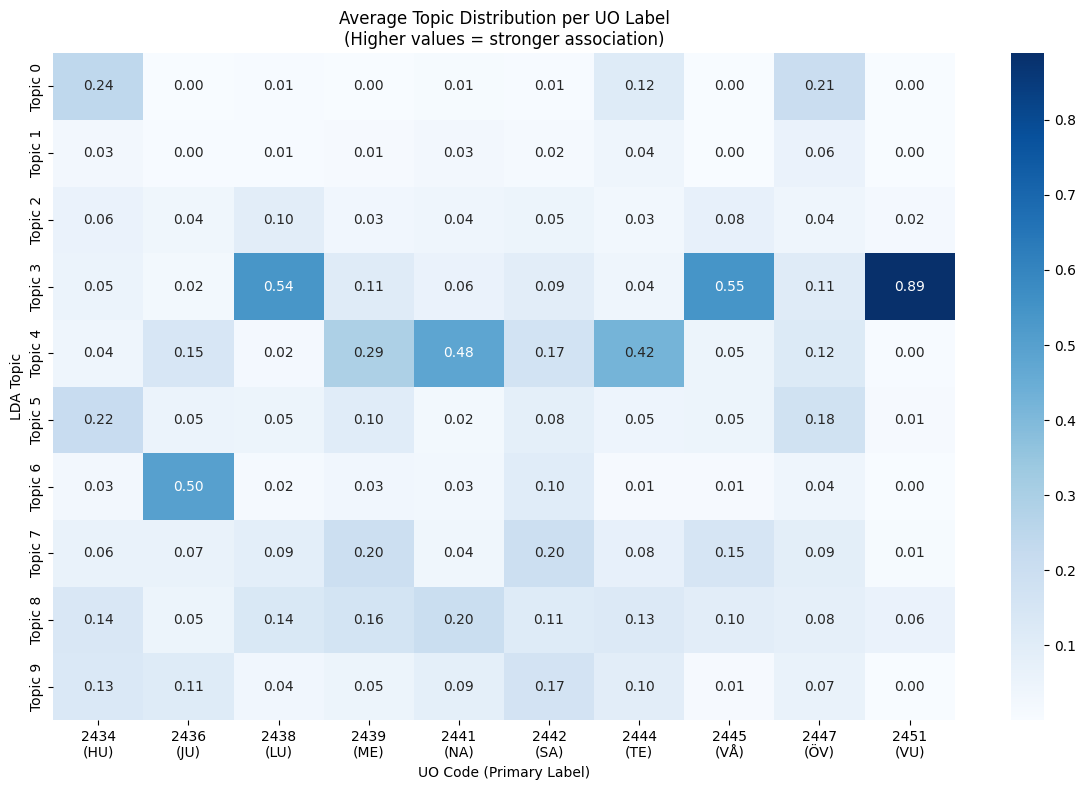


Saved: uo_topic_distribution.png


In [17]:
# Average Topic Distribution per UO


# Calculate mean topic distribution for each UO label
topic_cols = [f"topic_{i}" for i in range(N_TOPICS)]

uo_topic_means = df.groupby("primary_uo")[topic_cols].mean()

# Visualize
fig, ax = plt.subplots(figsize=(12, 8))

sns.heatmap(
    uo_topic_means.T,
    annot=True,
    fmt='.2f',
    cmap='Blues',
    xticklabels=[f"{uo}\n({UO_NAMES.get(uo, '?')[:8]})" for uo in uo_topic_means.index],
    yticklabels=[f"Topic {i}" for i in range(N_TOPICS)],
    ax=ax
)

ax.set_xlabel('UO Code (Primary Label)')
ax.set_ylabel('LDA Topic')
ax.set_title('Average Topic Distribution per UO Label\n(Higher values = stronger association)')

plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / 'uo_topic_distribution.png', dpi=150)
plt.show()

print("\nSaved: uo_topic_distribution.png")

In [18]:
# Topic Purity Analysis


# For each topic, calculate the "purity" (how concentrated it is in one UO)
def calculate_topic_purity(df, n_topics):
    """Calculate how 'pure' each topic is in terms of UO labels."""
    results = []
    
    for topic_id in range(n_topics):
        topic_docs = df[df["dominant_topic"] == topic_id]
        if len(topic_docs) == 0:
            continue
            
        uo_dist = topic_docs["primary_uo"].value_counts(normalize=True)
        
        results.append({
            'topic': topic_id,
            'n_docs': len(topic_docs),
            'dominant_uo': uo_dist.index[0],
            'dominant_uo_name': UO_NAMES.get(uo_dist.index[0], '?'),
            'purity': uo_dist.iloc[0],  # proportion in dominant UO
            'entropy': -(uo_dist * np.log2(uo_dist + 1e-10)).sum(),  # label entropy
            'n_unique_uo': len(uo_dist)
        })
    
    return pd.DataFrame(results)

purity_df = calculate_topic_purity(df, N_TOPICS)
print("\n" + "="*60)
print("TOPIC PURITY ANALYSIS")
print("="*60)
print("(Purity = proportion of topic's documents in the dominant UO)\n")
print(purity_df.to_string(index=False))

# Summary
print(f"\nAverage topic purity: {purity_df['purity'].mean():.3f}")
print(f"Topics with >50% purity: {(purity_df['purity'] > 0.5).sum()}/{N_TOPICS}")


TOPIC PURITY ANALYSIS
(Purity = proportion of topic's documents in the dominant UO)

 topic  n_docs  dominant_uo dominant_uo_name   purity  entropy  n_unique_uo
     0    1130         2434               HU 0.815929 0.891833            6
     1     157         2434               HU 0.433121 1.607570            5
     2     428         2434               HU 0.432243 2.264631            9
     3    1100         2438               LU 0.221818 2.845738           10
     4    2053         2441               NA 0.488066 2.086375            8
     5    1055         2434               HU 0.721327 1.305926            8
     6     644         2436               JU 0.588509 1.494340            6
     7     765         2442               SA 0.600000 1.883656            9
     8    1327         2434               HU 0.346647 2.352959            9
     9    1111         2434               HU 0.431143 1.912251            9

Average topic purity: 0.508
Topics with >50% purity: 4/10


## 5. Identifying Divergent Cases

These are courses where the topic distribution suggests a different classification than the official label.

In [19]:
# Find Topic-Label Mismatches

# Create a mapping from topic to "expected" UO based on plurality
topic_to_expected_uo = purity_df.set_index('topic')['dominant_uo'].to_dict()

# For each course, check if dominant topic's expected UO matches actual label
df["expected_uo_from_topic"] = df["dominant_topic"].map(topic_to_expected_uo)
df["topic_label_mismatch"] = df["primary_uo"] != df["expected_uo_from_topic"]

# Calculate "divergence score" - how much the topic distribution differs from expected
def calculate_divergence(row, topic_to_uo, uo_topic_means):
    """Calculate how much a document's topic dist differs from its label's typical distribution."""
    actual_uo = row["primary_uo"]
    if actual_uo not in uo_topic_means.index:
        return 0.0
    
    expected_dist = uo_topic_means.loc[actual_uo].values
    actual_dist = row[[f"topic_{i}" for i in range(len(expected_dist))]].values
    
    # Cosine distance
    dot = np.dot(expected_dist, actual_dist)
    norm = np.linalg.norm(expected_dist) * np.linalg.norm(actual_dist)
    if norm == 0:
        return 0.0
    return 1 - (dot / norm)

df["topic_divergence"] = df.apply(
    lambda row: calculate_divergence(row, topic_to_expected_uo, uo_topic_means),
    axis=1
)

print(f"Courses with topic-label mismatch: {df['topic_label_mismatch'].sum()} ({100*df['topic_label_mismatch'].mean():.1f}%)")
print(f"\nDivergence score statistics:")
print(df["topic_divergence"].describe())

Courses with topic-label mismatch: 4811 (49.2%)

Divergence score statistics:
count    9770.000000
mean        0.334733
std         0.201662
min         0.000139
25%         0.165329
50%         0.327545
75%         0.482160
max         0.918838
Name: topic_divergence, dtype: float64


In [20]:
# Most Divergent Cases for Error Analysis


# Select top divergent cases
top_divergent = df.nlargest(20, "topic_divergence")[
    ["id", "name", "primary_uo", "dominant_topic", "topic_confidence", 
     "topic_divergence", "labels_uo", "labels_pct"]
].copy()

top_divergent["primary_uo_name"] = top_divergent["primary_uo"].map(UO_NAMES)
top_divergent["expected_uo"] = top_divergent["dominant_topic"].map(topic_to_expected_uo)
top_divergent["expected_uo_name"] = top_divergent["expected_uo"].map(UO_NAMES)

print("\n" + "="*60)
print("TOP 20 MOST DIVERGENT CASES")
print("(Topic distribution differs most from label's typical pattern)")
print("="*60 + "\n")

for idx, row in top_divergent.iterrows():
    print(f"Course ID: {row['id']}")
    print(f"  Name: {row['name'][:80]}...")
    print(f"  Official Label: {row['primary_uo']} ({row['primary_uo_name']})")
    print(f"  Dominant Topic: {row['dominant_topic']} → suggests {row['expected_uo_name']}")
    print(f"  Divergence Score: {row['topic_divergence']:.3f}")
    print(f"  Topic Confidence: {row['topic_confidence']:.3f}")
    print()


TOP 20 MOST DIVERGENT CASES
(Topic distribution differs most from label's typical pattern)

Course ID: 18962
  Name: Special Education, Disability and Learning...
  Official Label: 2445 (VÅ)
  Dominant Topic: 9 → suggests HU
  Divergence Score: 0.919
  Topic Confidence: 0.563

Course ID: 14510
  Name: Uppdragsprojekt inom samhällsplanering...
  Official Label: 2444 (TE)
  Dominant Topic: 2 → suggests HU
  Divergence Score: 0.919
  Topic Confidence: 0.922

Course ID: 14510
  Name: Uppdragsprojekt inom samhällsplanering...
  Official Label: 2444 (TE)
  Dominant Topic: 2 → suggests HU
  Divergence Score: 0.919
  Topic Confidence: 0.922

Course ID: 14510
  Name: Uppdragsprojekt inom samhällsplanering...
  Official Label: 2444 (TE)
  Dominant Topic: 2 → suggests HU
  Divergence Score: 0.919
  Topic Confidence: 0.922

Course ID: 14510
  Name: Uppdragsprojekt inom samhällsplanering...
  Official Label: 2444 (TE)
  Dominant Topic: 2 → suggests HU
  Divergence Score: 0.919
  Topic Confidence: 

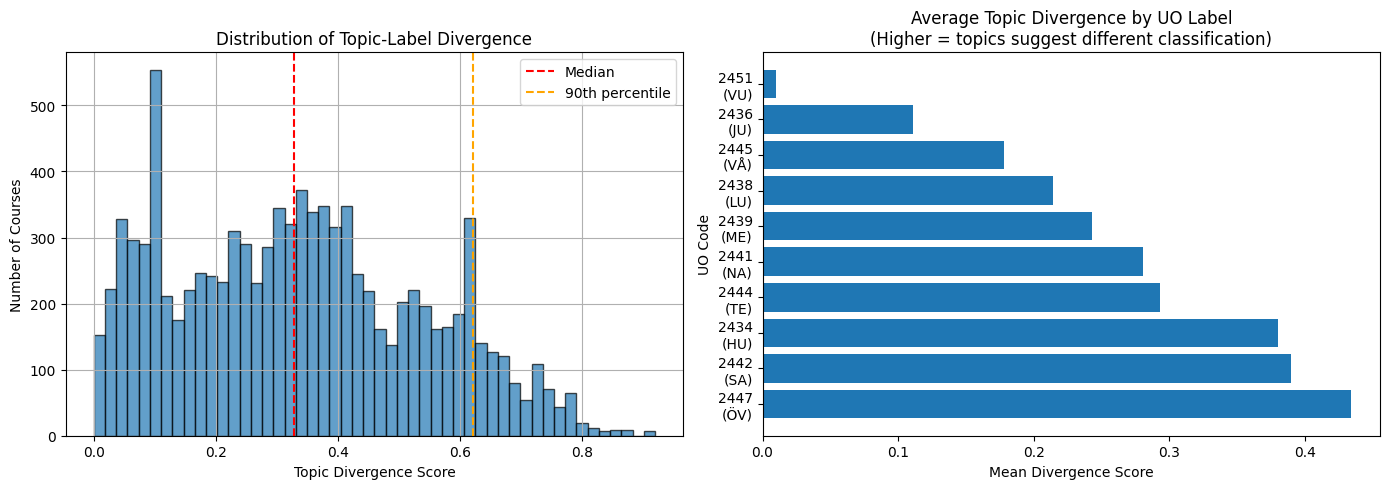


Saved: divergence_analysis.png


In [21]:
# Divergence Distribution by UO


fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution of divergence scores
ax1 = axes[0]
df["topic_divergence"].hist(bins=50, ax=ax1, edgecolor='black', alpha=0.7)
ax1.axvline(df["topic_divergence"].median(), color='red', linestyle='--', label='Median')
ax1.axvline(df["topic_divergence"].quantile(0.9), color='orange', linestyle='--', label='90th percentile')
ax1.set_xlabel('Topic Divergence Score')
ax1.set_ylabel('Number of Courses')
ax1.set_title('Distribution of Topic-Label Divergence')
ax1.legend()

# Divergence by UO
ax2 = axes[1]
uo_divergence = df.groupby("primary_uo")["topic_divergence"].mean().sort_values(ascending=False)
uo_labels = [f"{uo}\n({UO_NAMES.get(uo, '?')[:8]})" for uo in uo_divergence.index]
ax2.barh(uo_labels, uo_divergence.values)
ax2.set_xlabel('Mean Divergence Score')
ax2.set_ylabel('UO Code')
ax2.set_title('Average Topic Divergence by UO Label\n(Higher = topics suggest different classification)')

plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / 'divergence_analysis.png', dpi=150)
plt.show()

print("\nSaved: divergence_analysis.png")

## 6. Multi-label Analysis

Analyze how topics distribute across multi-label courses.

In [23]:
# Note: If you get an error message, try rerunning the cell (somthing is not synching..)
# Topic Distribution for Multi-label vs Single-label Courses


multilabel_df = df[df["is_multilabel"]]
singlelabel_df = df[~df["is_multilabel"]]

print(f"Single-label courses: {len(singlelabel_df)}")
print(f"Multi-label courses: {len(multilabel_df)}")

# Compare topic entropy (diversity) between groups
def topic_entropy(row, n_topics):
    """Calculate entropy of topic distribution."""
    probs = [row[f"topic_{i}"] for i in range(n_topics)]
    probs = np.array(probs)
    probs = probs / probs.sum()  # normalize
    return -(probs * np.log2(probs + 1e-10)).sum()

df["topic_entropy"] = df.apply(lambda row: topic_entropy(row, N_TOPICS), axis=1)

print(f"\nTopic Entropy (higher = more mixed topics):")
print(f"  Single-label courses: {singlelabel_df['topic_entropy'].mean():.3f}")
print(f"  Multi-label courses:  {multilabel_df['topic_entropy'].mean():.3f}")

Single-label courses: 7088
Multi-label courses: 2682

Topic Entropy (higher = more mixed topics):
  Single-label courses: 1.555
  Multi-label courses:  1.540


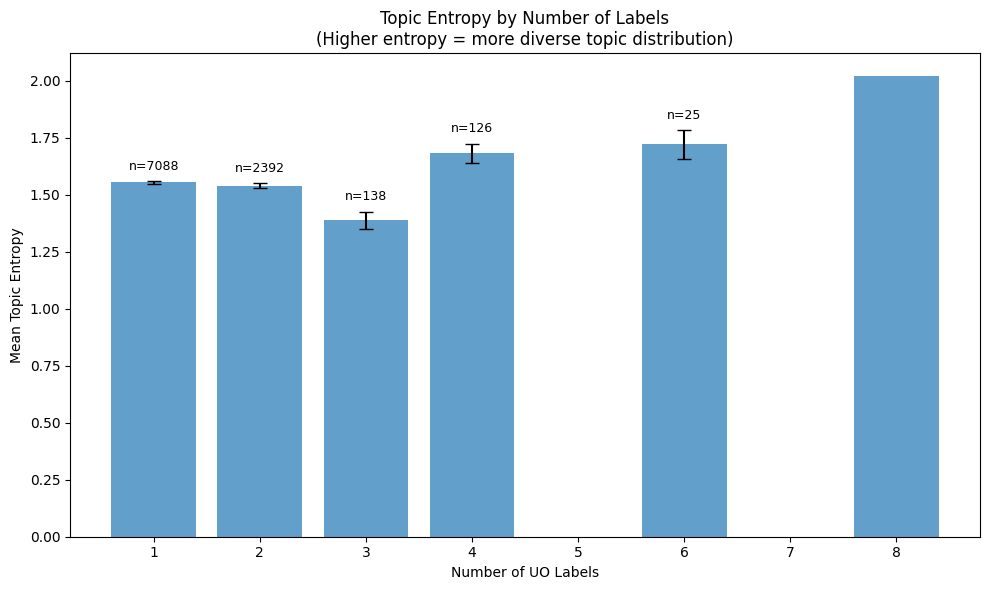


Saved: entropy_by_labels.png


In [24]:
# ========================
# Visualize Topic Entropy by Label Count
# ========================

fig, ax = plt.subplots(figsize=(10, 6))

entropy_by_nlabels = df.groupby("n_labels")["topic_entropy"].agg(['mean', 'std', 'count'])

ax.bar(entropy_by_nlabels.index, entropy_by_nlabels['mean'], 
       yerr=entropy_by_nlabels['std']/np.sqrt(entropy_by_nlabels['count']),
       capsize=5, alpha=0.7)

ax.set_xlabel('Number of UO Labels')
ax.set_ylabel('Mean Topic Entropy')
ax.set_title('Topic Entropy by Number of Labels\n(Higher entropy = more diverse topic distribution)')

# Add count annotations
for i, (idx, row) in enumerate(entropy_by_nlabels.iterrows()):
    ax.annotate(f'n={int(row["count"])}', 
                xy=(idx, row['mean'] + row['std']/np.sqrt(row['count']) + 0.05),
                ha='center', fontsize=9)

plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / 'entropy_by_labels.png', dpi=150)
plt.show()

print("\nSaved: entropy_by_labels.png")

## 7. Interactive Visualization with pyLDAvis

In [25]:
# pyLDAvis Visualization


if PYLDAVIS_AVAILABLE:
    print("Preparing pyLDAvis visualization...")
    
    # Prepare visualization
    vis_data = pyLDAvis.lda_model.prepare(lda, dtm, vectorizer, mds='mmds')
    
    # Save to HTML
    pyLDAvis.save_html(vis_data, str(ARTIFACTS_DIR / 'lda_visualization.html'))
    print(f"\nSaved interactive visualization: {ARTIFACTS_DIR / 'lda_visualization.html'}")
    
    # Display in notebook
    pyLDAvis.enable_notebook()
    pyLDAvis.display(vis_data)
else:
    print("pyLDAvis not available. Install with: pip install pyLDAvis")
    print("Skipping interactive visualization.")

Preparing pyLDAvis visualization...

Saved interactive visualization: /kaggle/working/topic_modeling/lda_visualization.html


## 8. Topic Interpretations and Summary

Based on the top words and correlations, we can try to interpret what each topic represents.

In [27]:
# Topic Summary Table


# Combine topic words with their dominant UO mapping
summary_data = []

for topic_idx in range(N_TOPICS):
    # Get top words
    top_words_idx = lda.components_[topic_idx].argsort()[:-11:-1]
    top_words = [feature_names[i] for i in top_words_idx]
    
    # Get purity info
    purity_row = purity_df[purity_df['topic'] == topic_idx].iloc[0] if len(purity_df[purity_df['topic'] == topic_idx]) > 0 else None
    
    summary_data.append({
        'Topic': topic_idx,
        'Top Words': ', '.join(top_words[:8]),
        'Dominant UO': purity_row['dominant_uo'] if purity_row is not None else None,
        'UO Name': purity_row['dominant_uo_name'] if purity_row is not None else None,
        'Purity': f"{purity_row['purity']:.2f}" if purity_row is not None else None,
        'N Docs': purity_row['n_docs'] if purity_row is not None else None
    })

summary_df = pd.DataFrame(summary_data)

print("\n" + "="*80)
print("TOPIC SUMMARY")
print("="*80 + "\n")
print(summary_df.to_string(index=False))

# Save summary
summary_df.to_csv(ARTIFACTS_DIR / 'topic_summary.csv', index=False)
print(f"\nSaved: topic_summary.csv")


TOPIC SUMMARY

 Topic                                                                                           Top Words  Dominant UO UO Name Purity  N Docs
     0                     texter, delkursen, resultat, grundläggande, olika, grammatik, svenska, redogöra         2434      HU   0.82    1130
     1                delkursen, tolkning, mellanöstern, global, kunskap, visa, grundläggande, kvalitativa         2434      HU   0.43     157
     2                      visa, visa förmåga, förmåga, diskutera, kunskap, språk, forskning, identifiera         2434      HU   0.43     428
     3                           olika, lärande, utifrån, utveckling, bedömning, perspektiv, elevers, barn         2438      LU   0.22    1100
     4                    grundläggande, olika, metoder, behandlar, redogöra, förväntas, modeller, begrepp         2441      NA   0.49    2053
     5                        delkursen, delkurs, redogöra, perspektiv, centrala, resultat, begrepp, olika         2434      H

In [28]:
# ========================
# Export Divergent Cases for Expert Review
# ========================

# Get top 50 divergent cases with full text for expert review
expert_review_df = df.nlargest(50, "topic_divergence")[
    ["id", "name", "text", "primary_uo", "labels_uo", "labels_pct",
     "dominant_topic", "topic_confidence", "topic_divergence"]
].copy()

expert_review_df["primary_uo_name"] = expert_review_df["primary_uo"].map(UO_NAMES)
expert_review_df["suggested_uo"] = expert_review_df["dominant_topic"].map(topic_to_expected_uo)
expert_review_df["suggested_uo_name"] = expert_review_df["suggested_uo"].map(UO_NAMES)

# Add topic distribution
for i in range(N_TOPICS):
    expert_review_df[f"topic_{i}_prob"] = df.loc[expert_review_df.index, f"topic_{i}"].values

# Save for expert review
expert_review_df.to_csv(ARTIFACTS_DIR / 'expert_review_cases.csv', index=False)
print(f"Saved {len(expert_review_df)} cases for expert review: expert_review_cases.csv")

Saved 50 cases for expert review: expert_review_cases.csv


## 9. Comparison: Different Numbers of Topics

Optionally, we can compare LDA models with different numbers of topics.

In [29]:
# ========================
# Compare Different Topic Numbers
# ========================

topic_range = [5, 8, 10, 12, 15]
perplexity_scores = []
coherence_approx = []  # Using topic-word probability entropy as proxy

for n_topics in topic_range:
    print(f"Training LDA with {n_topics} topics...", end=" ")
    
    lda_temp = LatentDirichletAllocation(
        n_components=n_topics,
        max_iter=10,  # fewer iterations for speed
        learning_method='online',
        random_state=RANDOM_SEED,
        n_jobs=-1
    )
    lda_temp.fit(dtm)
    
    perp = lda_temp.perplexity(dtm)
    perplexity_scores.append(perp)
    
    # Approximate coherence using topic concentration
    topic_word_entropy = -np.sum(lda_temp.components_ / lda_temp.components_.sum(axis=1, keepdims=True) * 
                                  np.log(lda_temp.components_ / lda_temp.components_.sum(axis=1, keepdims=True) + 1e-10))
    coherence_approx.append(topic_word_entropy / n_topics)
    
    print(f"Perplexity: {perp:.2f}")

print("\nDone.")

Training LDA with 5 topics... Perplexity: 1276.50
Training LDA with 8 topics... Perplexity: 1243.31
Training LDA with 10 topics... Perplexity: 1201.52
Training LDA with 12 topics... Perplexity: 1164.53
Training LDA with 15 topics... Perplexity: 1143.28

Done.


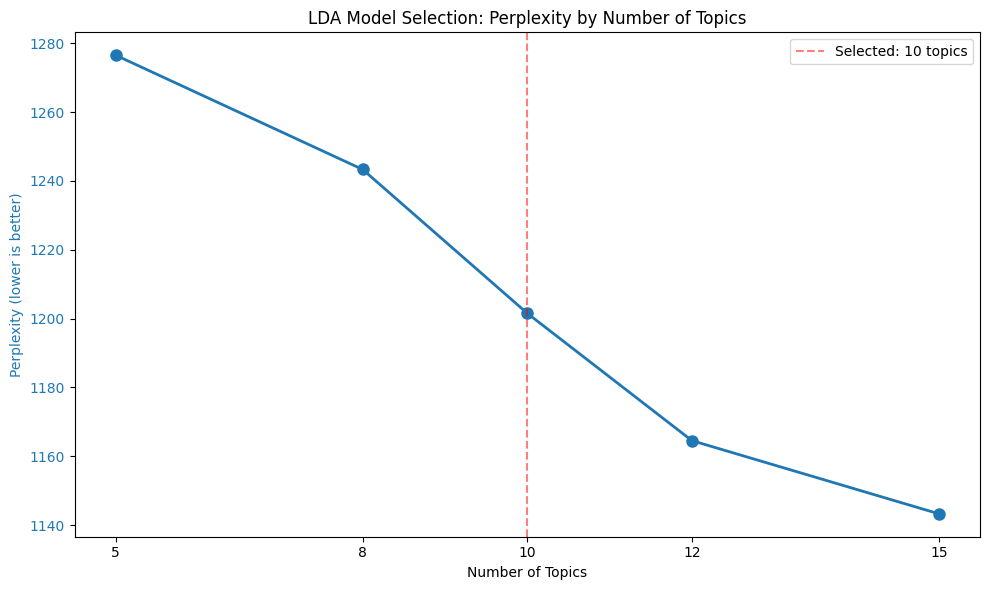


Saved: topic_number_comparison.png


In [30]:
# Visualize Topic Number Comparison


fig, ax1 = plt.subplots(figsize=(10, 6))

color = 'tab:blue'
ax1.set_xlabel('Number of Topics')
ax1.set_ylabel('Perplexity (lower is better)', color=color)
ax1.plot(topic_range, perplexity_scores, 'o-', color=color, linewidth=2, markersize=8)
ax1.tick_params(axis='y', labelcolor=color)

# Mark the chosen number of topics
ax1.axvline(x=N_TOPICS, color='red', linestyle='--', alpha=0.5, label=f'Selected: {N_TOPICS} topics')
ax1.legend(loc='upper right')

ax1.set_title('LDA Model Selection: Perplexity by Number of Topics')
ax1.set_xticks(topic_range)

plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / 'topic_number_comparison.png', dpi=150)
plt.show()

print("\nSaved: topic_number_comparison.png")

## 10. Key Findings Summary

In [32]:
# Summary Statistics


print("\n" + "="*80)
print("KEY FINDINGS SUMMARY")
print("="*80)

print(f"\n1. DATASET:")
print(f"   - Total course versions: {len(df)}")
print(f"   - Unique courses: {df['id'].nunique()}")
print(f"   - Multi-label courses: {df['is_multilabel'].sum()} ({100*df['is_multilabel'].mean():.1f}%)")

print(f"\n2. TOPIC MODEL:")
print(f"   - Number of topics: {N_TOPICS}")
print(f"   - Vocabulary size: {len(feature_names)}")
print(f"   - Model perplexity: {lda.perplexity(dtm):.2f}")

print(f"\n3. TOPIC-LABEL ALIGNMENT:")
print(f"   - Average topic purity: {purity_df['purity'].mean():.3f}")
print(f"   - Topics with >50% purity: {(purity_df['purity'] > 0.5).sum()}/{N_TOPICS}")
print(f"   - Topics with >70% purity: {(purity_df['purity'] > 0.7).sum()}/{N_TOPICS}")

print(f"\n4. DIVERGENT CASES:")
print(f"   - Courses with topic-label mismatch: {df['topic_label_mismatch'].sum()}")
print(f"   - High divergence (>90th percentile): {(df['topic_divergence'] > df['topic_divergence'].quantile(0.9)).sum()}")
print(f"   - Mean divergence score: {df['topic_divergence'].mean():.3f}")

print(f"\n5. MULTI-LABEL INSIGHTS:")
print(f"   - Single-label topic entropy: {singlelabel_df['topic_entropy'].mean():.3f}")
print(f"   - Multi-label topic entropy: {multilabel_df['topic_entropy'].mean():.3f}")
print(f"   - (Higher entropy = more mixed topic distribution)")

print(f"\n6. OUTPUT FILES:")
print(f"   - topic_uo_correlation.png")
print(f"   - uo_topic_distribution.png")
print(f"   - divergence_analysis.png")
print(f"   - entropy_by_labels.png")
print(f"   - topic_number_comparison.png")
print(f"   - topic_summary.csv")
print(f"   - expert_review_cases.csv")
if PYLDAVIS_AVAILABLE:
    print(f"   - lda_visualization.html")

print("\n" + "="*80)


KEY FINDINGS SUMMARY

1. DATASET:
   - Total course versions: 9770
   - Unique courses: 4880
   - Multi-label courses: 2682 (27.5%)

2. TOPIC MODEL:
   - Number of topics: 10
   - Vocabulary size: 5000
   - Model perplexity: 1194.13

3. TOPIC-LABEL ALIGNMENT:
   - Average topic purity: 0.508
   - Topics with >50% purity: 4/10
   - Topics with >70% purity: 2/10

4. DIVERGENT CASES:
   - Courses with topic-label mismatch: 4811
   - High divergence (>90th percentile): 976
   - Mean divergence score: 0.335

5. MULTI-LABEL INSIGHTS:
   - Single-label topic entropy: 1.555
   - Multi-label topic entropy: 1.540
   - (Higher entropy = more mixed topic distribution)

6. OUTPUT FILES:
   - topic_uo_correlation.png
   - uo_topic_distribution.png
   - divergence_analysis.png
   - entropy_by_labels.png
   - topic_number_comparison.png
   - topic_summary.csv
   - expert_review_cases.csv
   - lda_visualization.html



In [33]:
# Save Full Results

# Save full dataframe with topic assignments
df_export = df[[
    "id", "name", "primary_uo", "labels_uo", "labels_pct", "n_labels", "is_multilabel",
    "dominant_topic", "topic_confidence", "topic_divergence", "topic_entropy",
    "topic_label_mismatch", "expected_uo_from_topic"
] + [f"topic_{i}" for i in range(N_TOPICS)]].copy()

df_export.to_csv(ARTIFACTS_DIR / 'courses_with_topics.csv', index=False)
print(f"Saved full results: courses_with_topics.csv ({len(df_export)} rows)")

Saved full results: courses_with_topics.csv (9770 rows)
